<a href="https://colab.research.google.com/github/psiperez/budas_trade/blob/main/backtest_eurusd_envelope1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_491/1201678695.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('EURUSD=X', start='2025-03-14', end='2026-03-16', interval='1h')
[*********************100%***********************]  1 of 1 completed


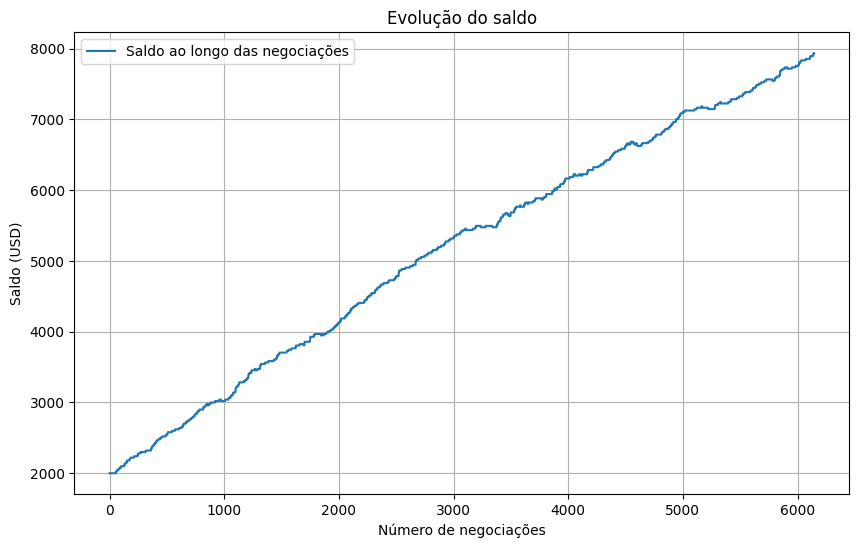

Lucro Líquido Total: 5936.21 USD
Fator de Lucro: 12.05
Índice Sharpe: 22.92
Retorno Esperado (Payoff): 17.46 USD
Drawdown Máximo: 0.90%
Total de negociações (incluindo parciais): 340


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def calculate_backtest():
    # 1. Download Data
    data = yf.download('EURUSD=X', start='2025-03-14', end='2026-03-16', interval='1h')
    if data.empty:
        print("Nenhum dado encontrado.")
        return

    # Pré-processamento
    df = data.copy()
    df.columns = [col[0] if isinstance(col, tuple) else col for col in df.columns]

    # 2. Indicador (ATR Envelope)
    inpAtrPeriod = 14
    inpDeviation = 1.5
    df['TR'] = 0.0
    for i in range(1, len(df)):
        df.loc[df.index[i], 'TR'] = max(df.iloc[i]['High'], df.iloc[i-1]['Close']) - min(df.iloc[i]['Low'], df.iloc[i-1]['Close'])
    df['ATR'] = df['TR'].rolling(window=inpAtrPeriod).mean()

    s_min = np.zeros(len(df))
    s_max = np.zeros(len(df))
    trend = np.zeros(len(df))

    for i in range(1, len(df)):
        atr = df.iloc[i]['ATR']
        if pd.isna(atr):
            continue
        dev = atr * inpDeviation
        val_h = df.iloc[i]['High']
        val_l = df.iloc[i]['Low']
        val_c = df.iloc[i]['Close']
        s_max[i] = val_h + dev
        s_min[i] = val_l - dev
        prev_trend = trend[i-1]
        prev_s_max = s_max[i-1]
        prev_s_min = s_min[i-1]
        if val_c > prev_s_max and prev_s_max > 0:
            trend[i] = 1
        elif val_c < prev_s_min and prev_s_min > 0:
            trend[i] = -1
        else:
            trend[i] = prev_trend
        if trend[i] > 0 and s_min[i] < prev_s_min:
            s_min[i] = prev_s_min
        if trend[i] < 0 and s_max[i] > prev_s_max:
            s_max[i] = prev_s_max

    df['Smin'] = s_min
    df['Smax'] = s_max
    df['Trend'] = trend

    # Simulação da estratégia
    balance = 2000  # saldo inicial
    risk_percent = 0.01
    rr_ratio = 2.5
    be_trigger_atr = 1.0
    trailing_multiplier = 1.5
    contract_size = 100000  # padrão EURUSD

    positions = []
    history = []
    saldo_evolucao = [balance]  # para gráfico
    drawdown_max = 0

    for i in range(2, len(df)):
        # Mudança de tendência
        if df.iloc[i]['Trend'] != df.iloc[i-1]['Trend'] and df.iloc[i-1]['Trend'] != 0:
            # Fechar posições existentes
            for p in positions:
                p['status'] = 'closed'
                p['exit_price'] = df.iloc[i]['Open']
                profit = (p['exit_price'] - p['entry_price']) * p['direction'] * p['lot_size'] * contract_size
                history.append(profit)
            positions = []
            # Abrir nova posição
            direction = df.iloc[i]['Trend']
            entry_price = df.iloc[i]['Open']
            sl = df.iloc[i-1]['Smax'] if direction == 1 else df.iloc[i-1]['Smin']
            if sl == 0:
                continue
            dist = abs(entry_price - sl)
            if dist == 0:
                continue
            tp = entry_price + dist * rr_ratio * direction
            risk_money = balance * risk_percent
            lot_size = risk_money / (dist * contract_size)
            positions.append({
                'entry_price': entry_price,
                'sl': sl,
                'tp': tp,
                'initial_sl': sl,
                'direction': direction,
                'lot_size': lot_size,
                'initial_vol': lot_size,
                'current_vol': lot_size,
                'be_protected': False,
                'p25': False, 'p50': False,
                'p75': False,
                'status': 'open'
            })
        # Gerenciamento
        high = df.iloc[i]['High']
        low = df.iloc[i]['Low']
        close = df.iloc[i]['Close']
        atr = df.iloc[i]['ATR']
        for p in positions[:]:
            if p['status'] != 'open':
                continue
            # Stop Loss
            sl_hit = (p['direction'] == 1 and low <= p['sl']) or (p['direction'] == -1 and high >= p['sl'])
            if sl_hit:
                profit = (p['sl'] - p['entry_price']) * p['direction'] * p['lot_size'] * contract_size
                history.append(profit)
                p['status'] = 'closed'
                positions.remove(p)
                continue
            # Take Profit
            tp_hit = (p['direction'] == 1 and high >= p['tp']) or (p['direction'] == -1 and low <= p['tp'])
            if tp_hit:
                profit = (p['tp'] - p['entry_price']) * p['direction'] * p['lot_size'] * contract_size
                history.append(profit)
                p['status'] = 'closed'
                positions.remove(p)
                continue
            # Parcial
            total_dist = abs(p['tp'] - p['entry_price'])
            current_profit = (close - p['entry_price']) * p['direction']
            progress = current_profit / total_dist if total_dist != 0 else 0
            if progress >= 0.25 and not p['p25']:
                close_lot = p['initial_vol'] * 0.25
                profit = (close - p['entry_price']) * p['direction'] * close_lot * contract_size
                history.append(profit)
                p['current_vol'] -= close_lot
                p['p25'] = True
                p['sl'] = p['entry_price']
            elif progress >= 0.50 and not p['p50']:
                close_lot = p['initial_vol'] * 0.25
                profit = (close - p['entry_price']) * p['direction'] * close_lot * contract_size
                history.append(profit)
                p['current_vol'] -= close_lot
                p['p50'] = True
            elif progress >= 0.75 and not p['p75']:
                close_lot = p['initial_vol'] * 0.25
                profit = (close - p['entry_price']) * p['direction'] * close_lot * contract_size
                history.append(profit)
                p['current_vol'] -= close_lot
                p['p75'] = True
            # Break-even ATR
            if not p['be_protected'] and current_profit >= atr * be_trigger_atr:
                p['sl'] = p['entry_price']
                p['be_protected'] = True
            # Trailing ATR
            if p['direction'] == 1:
                new_sl = close - atr * trailing_multiplier
                if new_sl > p['sl']:
                    p['sl'] = new_sl
            else:
                new_sl = close + atr * trailing_multiplier
                if new_sl < p['sl']:
                    p['sl'] = new_sl
        # Atualizar saldo
        saldo_atual = balance + np.sum(history)
        saldo_evolucao.append(saldo_atual)
        # Calcular o drawdown máximo
        max_saldo = max(saldo_evolucao)
        current_dd = (saldo_atual - max_saldo) / max_saldo * 100
        if current_dd < drawdown_max:
            drawdown_max = current_dd

    # Métricas finais
    if len(history) == 0:
        print("Nenhuma negociação.")
        return

    history = np.array(history)
    net_profit = np.sum(history)
    wins = history[history > 0]
    losses = history[history <= 0]
    profit_factor = abs(np.sum(wins) / np.sum(losses)) if len(losses) > 0 else np.inf
    avg_return = np.mean(history)
    std_return = np.std(history)
    sharpe = (avg_return / std_return) * np.sqrt(252) if std_return > 0 else 0
    payoff = net_profit / len(history)

    # Gráfico da evolução do saldo
    plt.figure(figsize=(10,6))
    plt.plot(saldo_evolucao, label='Saldo ao longo das negociações')
    plt.xlabel('Número de negociações')
    plt.ylabel('Saldo (USD)')
    plt.title('Evolução do saldo')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Exibir métricas
    print(f"Lucro Líquido Total: {net_profit:.2f} USD")
    print(f"Fator de Lucro: {profit_factor:.2f}")
    print(f"Índice Sharpe: {sharpe:.2f}")
    print(f"Retorno Esperado (Payoff): {payoff:.2f} USD")
    print(f"Drawdown Máximo: {abs(drawdown_max):.2f}%")
    print(f"Total de negociações (incluindo parciais): {len(history)}")

# Executar no notebook
calculate_backtest()